# Assignment 1 - Deep Learning And Generative AI

## In this project we will apply different deep learning methods in context of image and text processing and classification, and will compare some of them where applicable

### Part 1: Image classification

For this part of the project we will work with a very small dataset of dinosaur species to evaluate performance
of basic CNN and compare it with transfer learning models such as MobileNetV2 and ResNet50 to answer the question:
can a simple CNN model buit from scratch be trained and perform well on tiny dataset containing complex animal species (dinosaurs),
and what would be the difference in performance compared to pre-trained models.

Our dataset only includes 326 images span across 3 folders representing our dinosaur types (carnivore, herbivore, flying/aquatic), therefore it creates some challenges for deep learning models, which are normally trained and tested on large amount of data.


### Data exploration and preprocessing

In [ ]:
#Required imports
import random
import numpy as np
import tensorflow as tf
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
#Setting seed for random generation to ensure more consistent and reproduceable results
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Uploading our dataset
data_dir = "dinosaur_types"

#Setting image and batch sizes to be used consistently during further steps
img_size = (128,128)
batch_size = 16

#Splitting our dataset into training (80%) and validation (20%) subsets:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)
#Showing all classes
class_names = train_ds.class_names
print("Classes:", class_names)

Found 326 files belonging to 3 classes.
Using 261 files for training.
Found 326 files belonging to 3 classes.
Using 65 files for validation.
Classes: ['carnivore', 'flying,aquatic', 'herbivore']


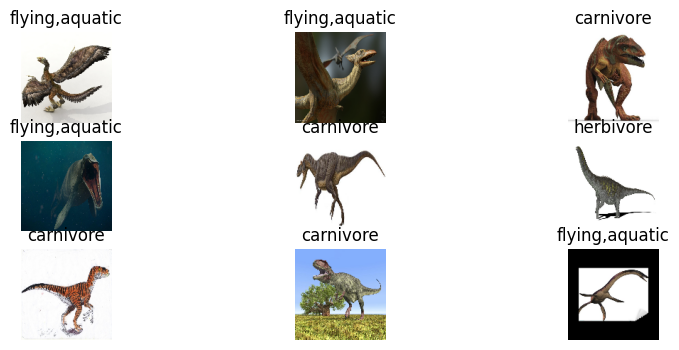

In [ ]:
#visualizing the data
plt.figure(figsize=(10, 4))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

As we could see from the previous steps, our dataset represents 326 images with 3 classes (~110 images per class);
all images will be resized to 128x128 resolution and put into batches of 16 images each.
Now, let's build a Convolutional model and try to train it on our data!

### Running a basic CNN model

In [ ]:
#Preparing our data and defining augmentation
AUTOTUNE = tf.data.AUTOTUNE

cnn_classes = train_ds.class_names
cnn_train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
cnn_val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

cnn_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

#Let's first run a basic CNN model with no specific settings or advanced augmentation
basic_model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),
    cnn_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(cnn_classes), activation='softmax')
])

basic_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

basic_model.fit(cnn_train_ds, validation_data=cnn_val_ds, epochs=30)

Epoch 1/30


C:\Users\SleepLess\Downloads\progs\python\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step - accuracy: 0.3563 - loss: 1.4387 - val_accuracy: 0.4462 - val_loss: 1.0594
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.4253 - loss: 1.0450 - val_accuracy: 0.4000 - val_loss: 1.0186
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.4291 - loss: 1.0363 - val_accuracy: 0.4154 - val_loss: 1.0096
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.4636 - loss: 0.9925 - val_accuracy: 0.5385 - val_loss: 0.9311
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.5287 - loss: 0.9775 - val_accuracy: 0.4462 - val_loss: 0.9405
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.5402 - loss: 0.9383 - val_accuracy: 0.5692 - val_loss: 0.8202
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.6092 - loss: 0.8559 - val_accuracy: 0.5077 - val_loss: 0.8727
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.6092 - loss: 0.8320 - val_accuracy: 0.6462 - val_

We can see that the model is learning: validation accuracy grows up to 75% before it goes slightly down again, while training accuracy goes much higher, slightly overfitting on our data.

Now, let's try to adjust some setups in our model: we can use more lightweight model with less dencity and smaller filters,
and increase learning rate to let model escape local minima. We will also give it more time to learn using more epochs

In [ ]:
#Let's try again with a bit different model and making sure we are not using data previously processed in training, so we extract and shuffle again:
light_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

light_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

light_classes = light_train_ds.class_names
print("Classes:", light_classes)

normalization_layer = tf.keras.layers.Rescaling(1./255)

light_train_ds = light_train_ds.cache()
light_train_ds = light_train_ds.shuffle(1000)

light_val_ds = light_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#Now performing data augmentation
light_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1)
])

light_train_ds = light_train_ds.prefetch(AUTOTUNE)

Found 326 files belonging to 3 classes.
Using 261 files for training.
Found 326 files belonging to 3 classes.
Using 65 files for validation.
Classes: ['carnivore', 'flying,aquatic', 'herbivore']


Now we will adjust some hyperparameters, making our model a bit more lightweight (reducing conv layers size and adding moderate dropout) and will train again to see difference in model's performance

In [ ]:
#Trying more lightweight model adding a little layer dropout
light_model = keras.Sequential([

    layers.Rescaling(1./255, input_shape=(128,128,3)),
    light_augmentation,

    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(len(light_classes), activation='softmax')
])

#Now training improved model with more patient approach: higher learning rate to escape local minima, more epochs
light_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0009),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = light_model.fit(
    light_train_ds,
    epochs=50,
    validation_data=light_val_ds,
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.3295 - loss: 1.2328 - val_accuracy: 0.4769 - val_loss: 1.0706
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.4521 - loss: 1.0640 - val_accuracy: 0.5538 - val_loss: 0.9819
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.4789 - loss: 1.0334 - val_accuracy: 0.5846 - val_loss: 0.9159
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5249 - loss: 0.9736 - val_accuracy: 0.6769 - val_loss: 0.8088
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5441 - loss: 0.9527 - val_accuracy: 0.7077 - val_loss: 0.7750
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.6092 - loss: 0.8781 - val_accuracy: 0.6769 - val_loss: 0.7975
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6054 - loss: 0.8385 - val_accuracy: 0.6615 - val_loss: 0.8850
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5709 - loss: 0.8747 - val_accuracy: 0.7538 - 

### Let's try to tune our model a little bit more by adding some density to the layers and applying regularization

In [ ]:
top_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    seed=123,
    validation_split=0.2,
    subset="training"
)

top_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    seed=123,
    validation_split=0.2,
    subset="validation"
)

top_classes = top_train_ds.class_names
print("Classes:", top_classes)

top_train_ds = top_train_ds.cache()
top_train_ds = top_train_ds.shuffle(1000)
top_train_ds = top_train_ds.prefetch(AUTOTUNE)
top_val_ds = top_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#Now performing data augmentation
top_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

#also adding some regularization
from tensorflow.keras import regularizers
top_model = keras.Sequential([

    layers.Rescaling(1./255, input_shape=(128,128,3)),
    top_data_augmentation,

    layers.Conv2D(32, 3, activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(64, activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.45),
    layers.Dense(len(top_classes), activation='softmax')
])

#Now training improved model with more patient approach: higher learning rate to escape local minima, more epochs
top_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0009),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7)
]
top_history = top_model.fit(
    top_train_ds,
    epochs=50,
    validation_data=top_val_ds,
    callbacks=callbacks,
    verbose=1
)

Found 326 files belonging to 3 classes.
Using 261 files for training.
Found 326 files belonging to 3 classes.
Using 65 files for validation.
Classes: ['carnivore', 'flying,aquatic', 'herbivore']
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 254ms/step - accuracy: 0.3640 - loss: 1.8884 - val_accuracy: 0.3385 - val_loss: 1.2197 - learning_rate: 9.0000e-04
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.3602 - loss: 1.2162 - val_accuracy: 0.4000 - val_loss: 1.2014 - learning_rate: 9.0000e-04
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.3793 - loss: 1.2008 - val_accuracy: 0.4308 - val_loss: 1.1745 - learning_rate: 9.0000e-04
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.4866 - loss: 1.1591 - val_accuracy: 0.4923 - val_loss: 1.1338 - learning_rate: 9.0000e-04
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.4559 - loss: 1.1635 - val_accuracy: 0.6000 - val_loss: 1.1129 - learning_rate: 9.0000e-04
Epoch 6/50
17/17 ━━━━━━━━

### Much better performance now! Looks like our CNN model successfully converged: epoch 36 — val accuracy 81.5%, val loss 0.7187, restore_best_weights=True should have saved the weights.

let's evaluate results:

### CNN Model - evaluating performance and visualizing results

In [ ]:
#Evaluating results:
y_true = []
y_pred = []

for images, labels in top_val_ds:
    preds = top_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=top_classes))

                precision    recall  f1-score   support

     carnivore       0.84      0.81      0.82        26
flying,aquatic       0.81      0.85      0.83        20
     herbivore       0.79      0.79      0.79        19

      accuracy                           0.82        65
     macro avg       0.81      0.82      0.81        65
  weighted avg       0.82      0.82      0.82        65



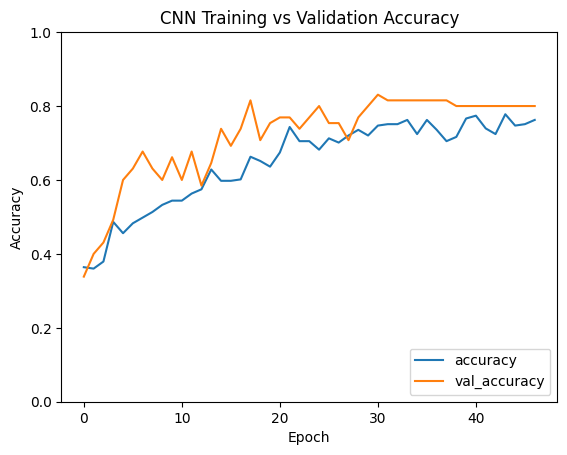

5/5 - 0s - 41ms/step - accuracy: 0.8154 - loss: 0.7367
Validation accuracy: 0.8154


In [ ]:
plt.plot(top_history.history['accuracy'], label='accuracy')
plt.plot(top_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('CNN Training vs Validation Accuracy')
plt.show()
test_loss, test_acc = top_model.evaluate(top_val_ds, verbose=2)
print(f"Validation accuracy: {test_acc:.4f}")

{np.int32(0), np.int32(1), np.int32(2)}
{np.int64(0), np.int64(1), np.int64(2)}


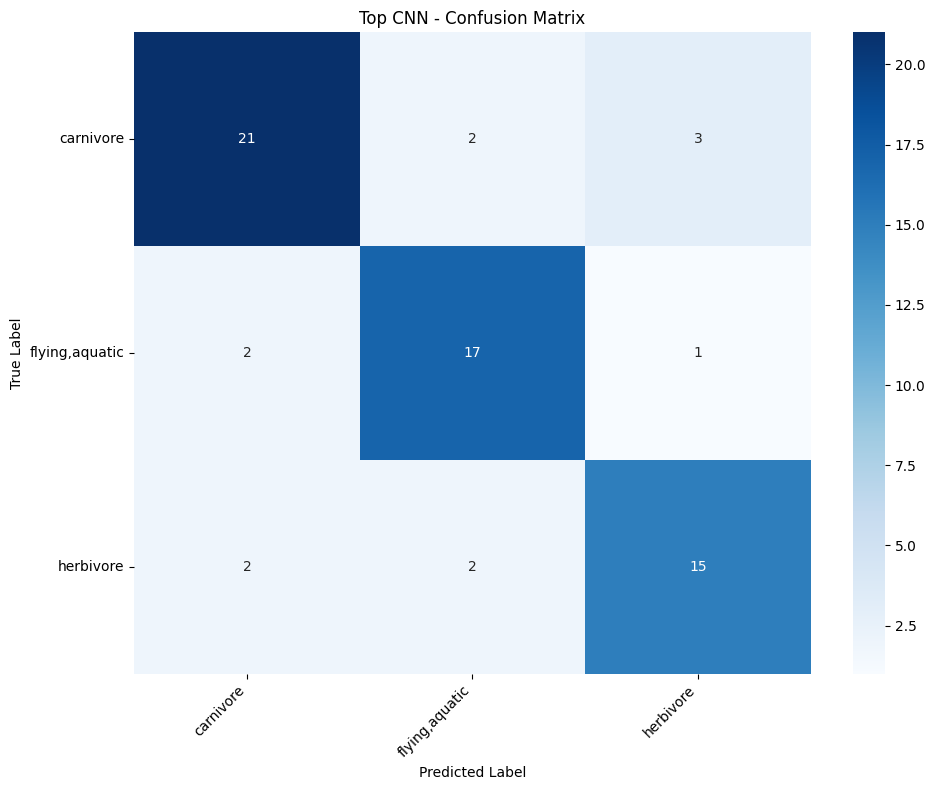

In [ ]:
#Building a confusion matrix
y_true_top = []
y_pred_top = []

for images, labels in top_val_ds:
    preds = top_model.predict(images, verbose=0)
    y_true_top.extend(labels.numpy())
    y_pred_top.extend(np.argmax(preds, axis=1))

# Verify before plotting
print(set(y_true_top))
print(set(y_pred_top))

cm = confusion_matrix(y_true_top, y_pred_top)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=top_classes,
    yticklabels=top_classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Top CNN - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Transfer Learning: comparing performance with pre-trained models

Now let's compare performance with pretrained MobileNetV2 model

### MobileNetV2

In [ ]:
#Loading subsets from raw data again making sure nothing would leak from previous trainings
mobilenet_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    seed=123,
    validation_split=0.2,
    subset="training"
).cache().shuffle(1000).prefetch(AUTOTUNE)

mobilenet_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    seed=123,
    validation_split=0.2,
    subset="validation"
).cache().prefetch(AUTOTUNE)

#and loading class_names separately for the same reason
mobilenet_class_names = tf.keras.utils.image_dataset_from_directory(
    data_dir, image_size=img_size, batch_size=batch_size
).class_names
print("Classes:", mobilenet_class_names)

#performing more heavy augmentation for pre-trained model
mobilenet_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
], name="mobilenet_augmentation")

#Building a model:
base_mobile = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_mobile.trainable = False

mobilenet_model = keras.Sequential([
    layers.Rescaling(1./255),
    mobilenet_augmentation,
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(mobilenet_class_names), activation='softmax')
])

#Compliling and training the model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)

Found 326 files belonging to 3 classes.
Using 261 files for training.
Found 326 files belonging to 3 classes.
Using 65 files for validation.
Found 326 files belonging to 3 classes.
Classes: ['carnivore', 'flying,aquatic', 'herbivore']
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step - accuracy: 0.4444 - loss: 1.3635 - val_accuracy: 0.5385 - val_loss: 0.8745
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.5785 - loss: 0.9400 - val_accuracy: 0.6000 - val_loss: 0.8162
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.6935 - loss: 0.7254 - val_accuracy: 0.7538 - val_loss: 0.6310
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.7318 - loss: 0.6674 - val_accuracy: 0.7692 - val_loss: 0.6161
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.7126 - loss: 0.6587 - val_accuracy: 0.8154 - val_loss: 0.5088
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.7701 - loss: 0.5823 - val_accuracy: 0.8154 - val_loss: 0.5

We can see that early stopping was triggered when the model converged on epoch 26 with 89% training accuracy and 89% of accuracy on validation set. But we can try to fine-tune now!

### MobileNet - Fine-tuning

In [ ]:
#We need to check how many layers we have in the model:
print(f"Total layers in base: {len(base_mobile.layers)}")



Total layers in base: 154


In [ ]:
#We can unfreeze last 30 layers, it can give us enough trainable parameters
base_mobile.trainable = True
for layer in base_mobile.layers[:-30]:
    layer.trainable = False

#Verifying before compiling, we can see how many trainable parameters we get:
trainable = sum([tf.size(v).numpy() for v in mobilenet_model.trainable_variables])
print(f"Trainable parameters: {trainable:,}")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=20,
)

Trainable parameters: 1,608,579
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 381ms/step - accuracy: 0.7471 - loss: 0.5901 - val_accuracy: 0.8923 - val_loss: 0.2720
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.7778 - loss: 0.4640 - val_accuracy: 0.8923 - val_loss: 0.3069
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step - accuracy: 0.8467 - loss: 0.4309 - val_accuracy: 0.8769 - val_loss: 0.3753
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step - accuracy: 0.9004 - loss: 0.2941 - val_accuracy: 0.8615 - val_loss: 0.4025
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step - accuracy: 0.8966 - loss: 0.3194 - val_accuracy: 0.8923 - val_loss: 0.3662
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.9080 - loss: 0.2530 - val_accuracy: 0.8923 - val_loss: 0.3582
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.9004 - loss: 0.2678 - val_accuracy: 0.8923 - val_loss: 0.3262
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.9004 

As it is shown in fine-tuning phase: the model has improved a little bit more, hitting the mark of 90% validation accuracy with 96% training accuracy. Let's evaluate results

### MobileNet performance evaluation and results visualization

In [ ]:
y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in mobilenet_val_ds:
    preds = mobilenet_model.predict(images, verbose=0)
    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(np.argmax(preds, axis=1))

print("Classification Report:")
print(classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=class_names,
    zero_division=0
))

Classification Report:
                precision    recall  f1-score   support

     carnivore       0.92      0.92      0.92        26
flying,aquatic       1.00      0.80      0.89        20
     herbivore       0.78      0.95      0.86        19

      accuracy                           0.89        65
     macro avg       0.90      0.89      0.89        65
  weighted avg       0.91      0.89      0.89        65



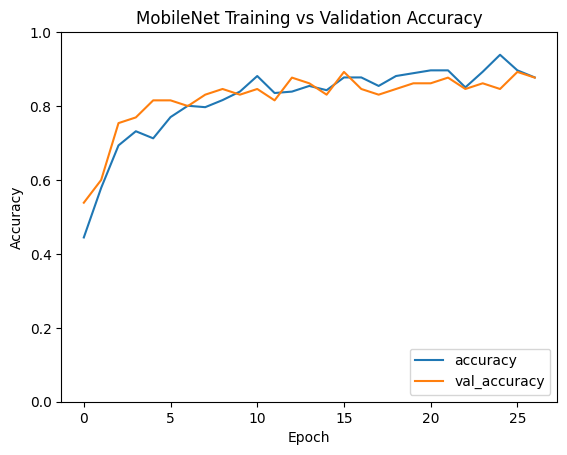

5/5 - 1s - 123ms/step - accuracy: 0.8923 - loss: 0.3045
Validation accuracy: 0.8923


In [ ]:
plt.plot(history_mobilenet.history['accuracy'], label='accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('MobileNet Training vs Validation Accuracy')
plt.show()
test_loss, test_acc = mobilenet_model.evaluate(mobilenet_val_ds, verbose=2)
print(f"Validation accuracy: {test_acc:.4f}")

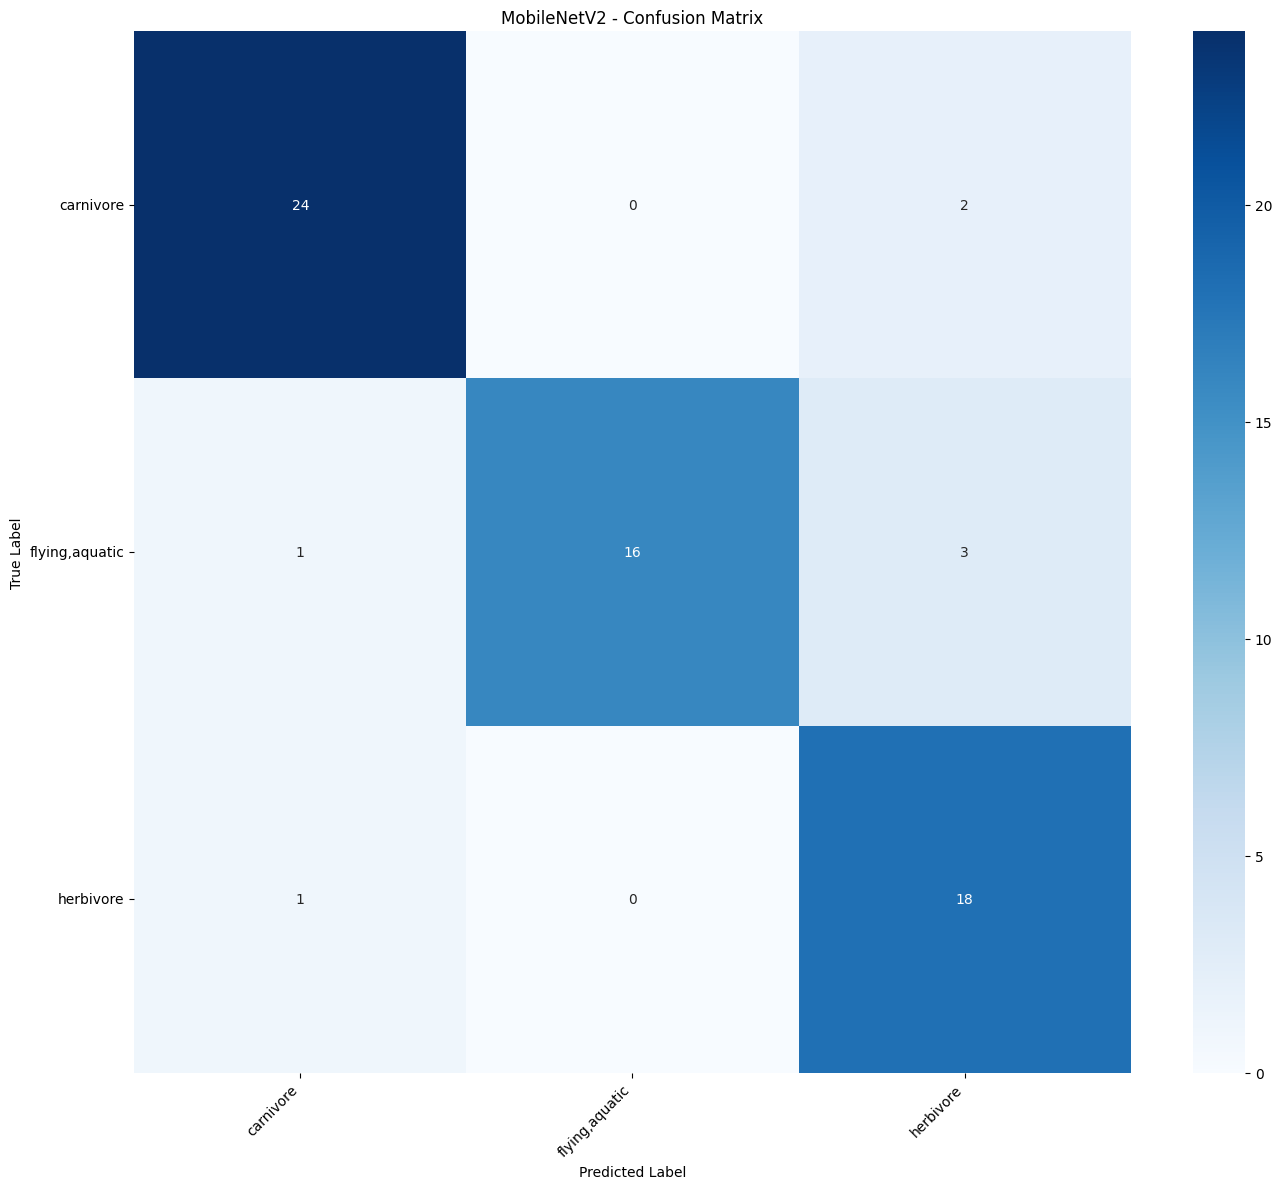

In [ ]:
cm2 = confusion_matrix(y_true_mobilenet, y_pred_mobilenet)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MobileNetV2 - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Now let's try to compare with ResNet model

## ResNet50

### Phase 1 - Training

In [ ]:
#Loading clean data again:
resnet_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    seed=123,
    validation_split=0.2,
    subset="training"
).cache().shuffle(1000).prefetch(AUTOTUNE)

resnet_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    seed=123,
    validation_split=0.2,
    subset="validation"
).cache().prefetch(AUTOTUNE)

resnet_class_names = tf.keras.utils.image_dataset_from_directory(
    data_dir, image_size=img_size, batch_size=batch_size
).class_names
print("Classes:", resnet_class_names)

#Applying augmentation
resnet_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
], name="resnet_augmentation")

#Building and compiling the model
resnet_base = tf.keras.applications.ResNet50(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

resnet_base.trainable = False

resnet_model = keras.Sequential([
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_augmentation,
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Training
history_resnet = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    #ResNet is much heavier model and will take more time to learn on such a tiny dataset
    epochs=50,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.3, min_lr=1e-7)
    ],
    verbose=1
)

Found 326 files belonging to 3 classes.
Using 261 files for training.
Found 326 files belonging to 3 classes.
Using 65 files for validation.
Found 326 files belonging to 3 classes.
Classes: ['carnivore', 'flying,aquatic', 'herbivore']
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 891ms/step - accuracy: 0.3908 - loss: 1.3682 - val_accuracy: 0.4308 - val_loss: 1.0777 - learning_rate: 5.0000e-04
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 640ms/step - accuracy: 0.4330 - loss: 1.2404 - val_accuracy: 0.5846 - val_loss: 0.9085 - learning_rate: 5.0000e-04
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 655ms/step - accuracy: 0.5211 - loss: 1.0080 - val_accuracy: 0.6615 - val_loss: 0.7793 - learning_rate: 5.0000e-04
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 647ms/step - accuracy: 0.4521 - loss: 1.0203 - val_accuracy: 0.5846 - val_loss: 0.8583 - learning_rate: 5.0000e-04
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 725ms/step - accuracy: 0.5556 - loss: 0.9769 - val_accuracy: 0.7692 - val_loss: 0.6854 - learni

### Phase 2 - Fine-tuning

In [ ]:
#Tuning the model: keeping weihts from previous phase, unfreezing top-20 layers
resnet_base.trainable = True
for layer in resnet_base.layers[:-20]:
    layer.trainable = False

#Verifying:
trainable = sum([tf.size(v).numpy() for v in resnet_model.trainable_variables])
print(f"Trainable parameters: {trainable:,}")

resnet_model.compile(
    #using different optimizer (SGD is widely recommended for fine-tuning by tensorflow)
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet_finetune = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)


Trainable parameters: 9,071,171
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6782 - loss: 0.7739 - val_accuracy: 0.7231 - val_loss: 0.7916
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 815ms/step - accuracy: 0.6552 - loss: 0.7871 - val_accuracy: 0.7385 - val_loss: 0.7422
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 815ms/step - accuracy: 0.6897 - loss: 0.7754 - val_accuracy: 0.7538 - val_loss: 0.7152
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 830ms/step - accuracy: 0.7011 - loss: 0.7320 - val_accuracy: 0.7385 - val_loss: 0.7175
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 921ms/step - accuracy: 0.7050 - loss: 0.7012 - val_accuracy: 0.7538 - val_loss: 0.7143
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 910ms/step - accuracy: 0.7318 - loss: 0.6778 - val_accuracy: 0.7538 - val_loss: 0.7074
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 893ms/step - accuracy: 0.7203 - loss: 0.7189 - val_accuracy: 0.7538 - val_loss: 0.6990
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 910ms/step - accuracy: 0.7

We can see that the accuracy for both training and validation sets has not improved that much during fine tuning, or it needs much more epochs to go through, but the model is heavy and takes too much time to converge.
So we can assume that ResNet model is rather too heavy for this tiny dataset, which prevented it from performing as good as MobileNet.  

### ResNet50 performance evaluation and visualization of results

In [ ]:
y_true_resnet = []
y_pred_resnet = []

for images, labels in mobilenet_val_ds:
    preds = resnet_model.predict(images, verbose=0)
    y_true_resnet.extend(labels.numpy())
    y_pred_resnet.extend(np.argmax(preds, axis=1))

print("Classification Report:")
print(classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=resnet_class_names,
    zero_division=0
))

Classification Report:
                precision    recall  f1-score   support

     carnivore       0.94      0.58      0.71        26
flying,aquatic       1.00      0.75      0.86        20
     herbivore       0.53      0.95      0.68        19

      accuracy                           0.74        65
     macro avg       0.82      0.76      0.75        65
  weighted avg       0.84      0.74      0.75        65



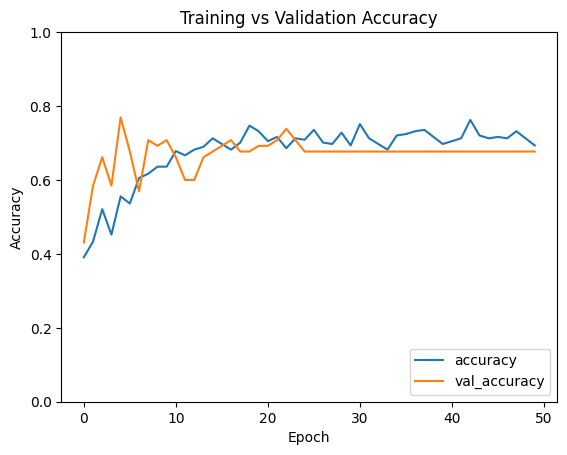

5/5 - 2s - 411ms/step - accuracy: 0.7385 - loss: 0.6839
Validation accuracy: 0.7385


In [ ]:
plt.plot(history_resnet.history['accuracy'], label='accuracy')
plt.plot(history_resnet.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.show()
test_loss, test_acc = resnet_model.evaluate(resnet_val_ds, verbose=2)
print(f"Validation accuracy: {test_acc:.4f}")

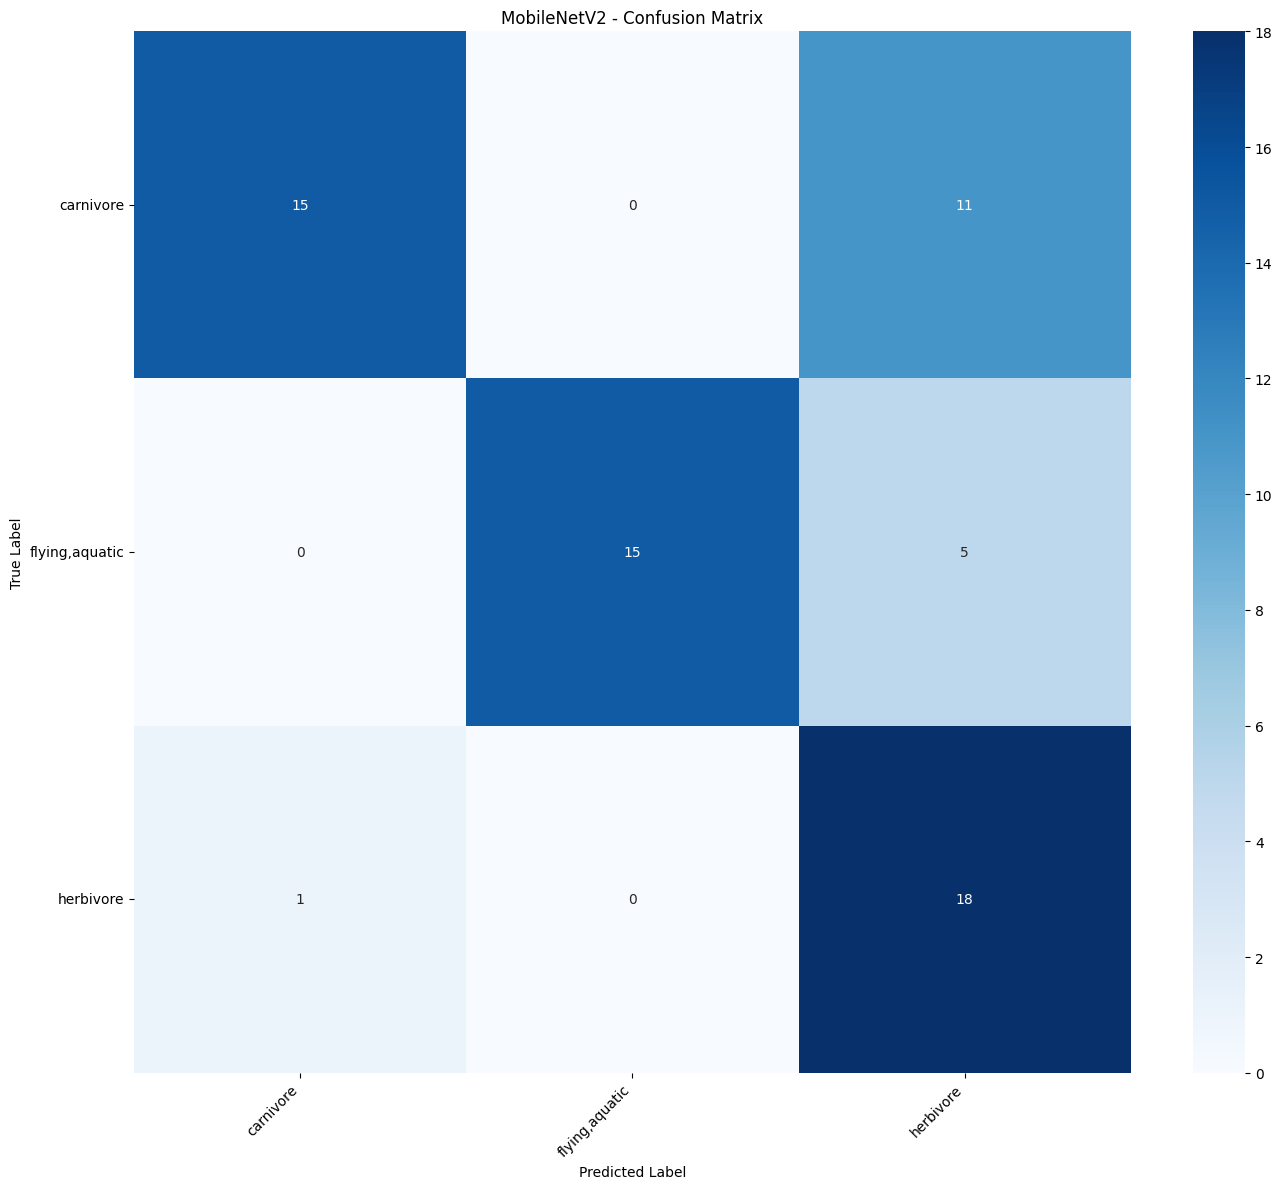

In [ ]:
cm3 = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=resnet_class_names,
    yticklabels=resnet_class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet50 - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

### We evaluated image classification performance of basic CNN model on a small multi-class dataset compared to transfer learning:
### The conducted research has demonstrated that transfer learning with lightweight pre-trained model (MobileNetV2) achieves high accuracy (90%) on extremely small dataset (326 images in total with 115 images/class), outperforming heavier architectures (ResNet50: 73%) and Convolutional Neural Network (75%).

### Proved MobileNetV2 transfer learning can achieve ImageNet-competitive accuracy (90%) with 1000x fewer training examples (although for dataset where number of classes is also small). This evaluation represents good methodology for deep learning scenarios where data collection is very limited and available dataset is tiny. This can be applicable in real-life industries, such as games, AR/VR, digital media where data constraints exist

### Despite clear pattern of performance differences and conclusions made, it is worth mentioning that due to the dataset being very small and the validation split is limited, these results should be interpreted as an exploratory comparison rather than a definitive benchmark.


# Part 2: Text processing, classification and interpretation

## Problem Statement

The objective is to classify news articles into categories:

- World
- Sports
- Business
- Sci/Tech

We will use AG News dataset, where all articles are allocated to the exact 4 categories above, and will apply RNN, LTSM and pretrained models to test models performance on classification task and evaluate learned text patterns.

## Data preparation and preprocessing

### Installing required libraries:

In [ ]:

!pip install datasets --quiet
!pip install lime
!pip install transformers tensorflow-text

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 2.8 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.9 MB 3.2 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.9 MB 3.5 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/11.9 MB 3.7 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/11.9 MB 4.3 MB/s eta 0:00:02
   --------------------- ------------------ 6.3/11.9 MB 5.0 MB/s eta 0:00:02
   ----

ERROR: Could not find a version that satisfies the requirement tensorflow-text (from versions: none)
ERROR: No matching distribution found for tensorflow-text


In [ ]:
#Running imports
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
import lime
import lime.lime_text

C:\Users\SleepLess\Downloads\progs\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'torch'

## Text preprocessing: converting and padding, tokenization

- Here we loaded the AG News dataset using the HuggingFace datasets library. This dataset consists of news articles broken down into four categories: World, Sports, Business, and Science/Technology. This will be used to train and test the models.
 - Data Splitting
We split the data into training, validation and testing sets (80/10/10 correspondently). We used stratified splitting so that all splits have the same representation of all categories.
- Tokenization (Text Preprocessing)
We used a tokenizer to convert text into numpy arrays.

In [ ]:
#Loading dataset
dataset = load_dataset("ag_news")
#Taking only ~1/10 of original dataset for demonstration purposes only (full dataset is too big and training goes too slow)
train_texts_full = list(dataset["train"]["text"])[:12000]
train_labels_full = list(dataset["train"]["label"])[:12000]

#Splitting dataset into 80/10/10 as train/test/validation
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    train_texts_full, train_labels_full,
    test_size=0.2, random_state=42, stratify=train_labels_full
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Final subsets:")
print(f"Train: {len(train_texts)} samples")
print(f"Val:   {len(val_texts)} samples")
print(f"Test: {len(test_texts)} samples")

## Text Preprocessing

Here we made sure that all the text segments are of the same length (256) and applied tokenization. This is needed for model training.

In [ ]:
#tokenization
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts + val_texts + test_texts)
vocab_size = 20000
max_len = 256

#Converting and padding
X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), maxlen=max_len)
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_texts), maxlen=max_len)
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=max_len)

y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

print(f"Tokenized subsets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test: {y_test.shape}")

Now, when the raw text from our dataset is converted into appropriate numpy arrays and is ready to be fed to RNN model, let's build a model and run it

## RNN Model Building and Training
Here we are building a Simple RNN model. It has an embedding layer that converts words to vectors, and an RNN layer to process the sequence. We added dense layers for classification. The model was trained on the training subset and tested on the test one.

In [ ]:
#Creating conventional RNN model:
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64, dropout=0.3),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Training the model
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)
#Testing performance
test_loss, test_accuracy = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"RNN Test Results:")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

### Tuning
Now we tried to improve the RNN model by increasing the number of neurons and adding dropout to avoid overfitting. We also used early stopping to stop training when the validation accuracy stopped improving and restore the best weights.

In [ ]:
#Trying to tune the model a bit, adding more regularization and early stopping:
rnn_model2 = Sequential([
     Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(128, dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])

rnn_model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

#Training the model
history_rnn2 = rnn_model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)
#Testing performance
test_loss, test_accuracy = rnn_model2.evaluate(X_test, y_test, verbose=0)
print(f"RNN Test Results:")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

### Let's analyze model's performance and try interprete learned features and representations

We prepared classification report and confusion matrix to evaluate the RNN model. The classification report provides precision, recall and F1-score and the confusion matrix shows where the model is making mistakes.

In [ ]:
y_pred = np.argmax(rnn_model.predict(X_test), axis=1)
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
#Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('AG News 4-Class Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

And let's get our model's hidden layers to explore learned representations and classes confidence using t-SNE:
We will see which clusters have more density (confident) and which ones are more spread out (less confident)

In [ ]:
from sklearn.manifold import TSNE
import plotly.express as px

#Extracting RNN's hidden states to see learned representations
embedding_layer = rnn_model.layers[0]
rnn_layer = rnn_model.layers[1]

#Extracting hidden states
X_embedded = embedding_layer(X_train[:2000])
hidden_states = rnn_layer(X_embedded).numpy()
hidden_states_flat = hidden_states.reshape(2000, -1)
print(f"Hidden shape: {hidden_states_flat.shape}")

#t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(hidden_states_flat)

#plotting
fig = px.scatter(x=embeddings_2d[:,0], y=embeddings_2d[:,1],
                color=y_train[:2000].astype(str),
                color_discrete_map={'0':'blue', '1':'green', '2':'orange', '3':'red'},
                labels={'color':'Class (0=World,1=Sports,2=Business,3=SciTech)'},
                title="RNN Representations: label clusters")
fig.show()

### LIME Explanation (RNN)
Here we are using LIME text explainer to explain the model predictions. It shows the important words of the text that affected the prediction. This helps in making the model interpretable and see what its desicions based on.

In [ ]:
#Interpreting learned representaions:
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

def predict_fn(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len)
    return rnn_model.predict(padded)
#We are using Lime text explainer here to explain predictions made by model
explainer = lime.lime_text.LimeTextExplainer(class_names=class_names)
for true_class in range(4):
    #only taking examples of correct predictions
    idx = np.where(y_test == true_class)[0][0]
    example_text = test_texts[idx]

    exp = explainer.explain_instance(example_text, predict_fn, num_features=10, num_samples=1000, top_labels=4)
    print(f"\n class {class_names[true_class]} example:")
    print(f"Text: {example_text[:150]}...")
    for i in range(4):
        exp_list = exp.as_list(label=i)
        top5 = exp_list[:5]
        print(f"  {class_names[i]}: {', '.join([f'{w}:{wgt:.2f}' for w,wgt in top5])}")

    exp.show_in_notebook()

## Building and Training LSTM Model
Now we will use LSTM Model (unlike RNN it has more advanced state handling with gates and keeps state longer).

Theoretically, LSTM should demonstrate better performance compared to RNN as its gates provide longer memory.

In [ ]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64, dropout=0.3),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])
#Compiling our model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#Training model
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)
#Testing
test_loss_lstm, test_acc_lstm = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ LSTM Results:")
print(f"Test Accuracy: {test_acc_lstm:.4f} ({test_acc_lstm*100:.2f}%)")
print(f"vs RNN: {test_accuracy:.1%}")

### Improving LSTM Model
We will try to tune the model by adding a dropout function and increasing the number of units to improve performance. We also used early stopping to prevent overfitting. It makes the model more stable and accurate.

In [ ]:
lstm_tuned = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(96, dropout=0.2, recurrent_dropout=0.1, return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

lstm_tuned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history_lstm = lstm_tuned.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=15, batch_size=128,
    callbacks=[early_stop], verbose=1
)

### Let's analyze LSTM performance in a similar way we did for RNN

Classification Report and Confusion Matrix:
The results show that LSTM performs better than the RNN model.


In [ ]:
y_pred = np.argmax(lstm_tuned.predict(X_test), axis=1)
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
#Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('AG News 4-Class Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### t-SNE Visualization (LSTM)
Similarly to RNN, we took the hidden states generated by the LSTM model and visualized them with t-SNE. More clearly separated clusters shows that LSTM learns better representations.

In [ ]:
#Extracting LSTM's hidden states to see learned representations
embedding_layer = lstm_tuned.layers[0]
lstm_layer = lstm_tuned.layers[1]

#Extracting hidden states
X_embedded = embedding_layer(X_train[:2000])
hidden_states = lstm_layer(X_embedded).numpy()
hidden_states_flat = hidden_states.reshape(2000, -1)
print(f"Hidden shape: {hidden_states_flat.shape}")

#t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(hidden_states_flat)

#plotting
fig = px.scatter(x=embeddings_2d[:,0], y=embeddings_2d[:,1],
                color=y_train[:2000].astype(str),
                color_discrete_map={'0':'blue', '1':'green', '2':'orange', '3':'red'},
                labels={'color':'Class (0=World,1=Sports,2=Business,3=SciTech)'},
                title="RNN Representations: label clusters")
fig.show()

### Lime Text Explainer:

Again, we applied LIME to interpret the LSTM predictions here. It shows which words matter most for classification and helps to compare with RNN explanations.

In [ ]:
#Interpreting learned representaions:
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

def predict_fn(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len)
    return lstm_tuned.predict(padded)
#We are using Lime text explainer here to explain predictions made by model
explainer = lime.lime_text.LimeTextExplainer(class_names=class_names)
for true_class in range(4):
    #only taking examples of correct predictions
    idx = np.where(y_test == true_class)[0][0]
    example_text = test_texts[idx]

    exp = explainer.explain_instance(example_text, predict_fn, num_features=10, num_samples=1000, top_labels=4)
    print(f"\n class {class_names[true_class]} example:")
    print(f"Text: {example_text[:150]}...")
    for i in range(4):
        exp_list = exp.as_list(label=i)
        top5 = exp_list[:5]
        print(f"  {class_names[i]}: {', '.join([f'{w}:{wgt:.2f}' for w,wgt in top5])}")

    exp.show_in_notebook()

### As we can see, LSTM slightly outperforms conventional RNN.

### Now let's try a pre-trained model and compare performance

## BERT:
In the following cell, we install libraries needed to use BERT like transformers and keras-hub.

In [ ]:
!pip install transformers
from transformers import AutoTokenizer, BertTokenizer, BertForSequenceClassification
import tensorflow_hub as hub
!pip install keras-hub
import keras_hub

### Checking Data for BERT
Before using BERT, we checked the data is in suitable format. We printed out sample texts, labels, and distributions to check out the data.

In [ ]:
#Double-checking our data is in suitable format for BERT: inputs should be raw text + labels
print(f"Train: {len(train_texts)} texts, {len(y_train)} labels")
print(f"Val:   {len(val_texts)} texts, {len(y_val)} labels")
print(f"Label distribution: {np.bincount(y_train)}")
print(f"Sample texts: {train_texts[:2]}")
print(f"Sample labels: {y_train[:5]}")

### Building and Training BERT Model
A pre-trained BERT model trained on large amount of text data and already understands language, we just fine-tuned it for our classification task. We trained it for a few epochs with a small learning rate.

In [ ]:
#Preparing preprocessor and loading a model from Keras Hub library
preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=128
)
bert_model = keras_hub.models.BertTextClassifier.from_preset(
    "bert_base_en_uncased",
    num_classes=4,
    preprocessor=preprocessor
)
#Compiling BERT model
bert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
#applying early stopping and training the model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=2, restore_best_weights=True
)
history_bert = bert_model.fit(
    x=train_texts,
    y=y_train,
    validation_data=(val_texts, y_val),
    epochs=4,
    batch_size=32,
    callbacks=[early_stop]
)

### Evaluating BERT model performance

Predictions report and confusion matrix:

Same implementation of classification report and confusion matrix. The results show that BERT outperforms both RNN and LSTM.


In [ ]:
y_pred_bert = np.argmax(bert_model.predict(test_texts), axis=1)

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

#Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_bert, target_names=class_names))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('AG News 4-Class Confusion Matrix - BERT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Models Performance Comparison

We have compared the accuracy of RNN, LSTM and BERT using a bar chart. This indicates that BERT has the highest accuracy.

In [ ]:
#Comparing accuracy of different models we used:
rnn_acc = history_rnn.history['val_accuracy'][-1]
lstm_acc = history_lstm.history['val_accuracy'][-1]
bert_acc = history_bert.history['val_accuracy'][-1]

models     = ['RNN', 'LSTM', 'BERT']
accuracies = [rnn_acc, lstm_acc, bert_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

print("RNN Accuracy:",  rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("BERT Accuracy:", bert_acc)

### Loss Comparison

Finally, we plotted the training loss of all models. This helps to explore how each model learns in time: if the loss is decreasing, it means that the model is learning well. We can see that BERT's loss function is standing our from RNN and LSTM results

## Conclusion

Overall, the results suggest a clear improvement from RNN to LSTM to BERT. RNN suffers from long sequences, but LSTM enhances performance with memory gates. BERT has the best results due to pre-trained knowledge and complex architecture.